In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.feature_extraction.text import CountVectorizer
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

In [2]:
# Find the project root automatically

current_path = Path.cwd()

for path in [current_path, *current_path.parents]:
    if (path / "pyproject.toml").exists():
        PROJECT_ROOT = path
        break
else:
    raise FileNotFoundError("Project root could not be found.")

RAW_DATA = PROJECT_ROOT / "data" / "raw"

feedback_file = RAW_DATA / "Online Retail Customer Feedback.csv"

print("Project root:", PROJECT_ROOT)
print("Feedback file:", feedback_file)

# Load feedback file without assuming a header

feedback_df = pd.read_csv(
    feedback_file,
    header=None,
    names=["feedback"]
)

print("\nFeedback dataset shape:", feedback_df.shape)

display(feedback_df.head(10))

print("\nColumns:")
print(feedback_df.columns.tolist())

Project root: c:\Users\Precision5540\Desktop\G7_Retail_Analytics_Final_Project
Feedback file: c:\Users\Precision5540\Desktop\G7_Retail_Analytics_Final_Project\data\raw\Online Retail Customer Feedback.csv

Feedback dataset shape: (965, 1)


,feedback
0,"customer support was slightly disappointing, b..."
1,"the experience was decent, and the final bille..."
2,Superr 10 out of 10
3,wow nice option
4,"i found the buying process to be quite good, t..."
5,", using the app was inconsistent, but billing ..."
6,"the ordering experience felt a bit confusing, ..."
7,"using the app was decent, but communication fr..."
8,"From my experience, the checkout process seeme..."
9,The experience was good



Columns:
['feedback']


In [3]:
print("Total feedback rows:", len(feedback_df))

print("\nMissing feedback:")
print(feedback_df["feedback"].isna().sum())

print("\nExact duplicate feedback:")
print(feedback_df["feedback"].duplicated().sum())

feedback_df["character_count"] = (
    feedback_df["feedback"]
    .astype(str)
    .str.len()
)

feedback_df["word_count"] = (
    feedback_df["feedback"]
    .astype(str)
    .str.split()
    .str.len()
)

print("\nFeedback length summary:")

display(
    feedback_df[
        ["character_count", "word_count"]
    ]
    .describe()
    .round(2)
)

print("\nShortest feedback examples:")

display(
    feedback_df[
        ["feedback", "word_count"]
    ]
    .sort_values("word_count")
    .head(10)
)

Total feedback rows: 965

Missing feedback:
0

Exact duplicate feedback:
1

Feedback length summary:


,character_count,word_count
count,965.00,965.00
mean,98.14,15.69
std,22.21,3.69
min,15.00,3.00
25%,83.00,13.00
50%,99.00,16.00
75%,113.00,18.00
max,162.00,28.00



Shortest feedback examples:


,feedback,word_count
3,wow nice option,3
53,"Goood, liked itt",3
596,It was worth buying,4
9,The experience was good,4
152,"Good good good ,very good",5
939,full marks keep it up,5
663,little costly but nice offers,5
41,Verry happy man good option,5
2,Superr 10 out of 10,5
155,"its is indeed good,worth recommending",5


In [4]:
duplicate_feedback = feedback_df[
    feedback_df["feedback"].duplicated(
        keep=False
    )
]

print("Duplicate feedback rows:")
display(duplicate_feedback)

leading_or_trailing_spaces = (
    feedback_df["feedback"]
    != feedback_df["feedback"].str.strip()
).sum()

print(
    "\nFeedbacks with leading or trailing spaces:",
    leading_or_trailing_spaces
)

Duplicate feedback rows:


,feedback,character_count,word_count
21,", my interaction with customer care was worse ...",59,10
54,", my interaction with customer care was worse ...",59,10



Feedbacks with leading or trailing spaces: 4


In [5]:
feedback_clean = feedback_df.copy()

feedback_clean["feedback"] = (
    feedback_clean["feedback"]
    .str.strip()
)

feedback_clean["feedback"] = (
    feedback_clean["feedback"]
    .str.replace(r"\s+", " ", regex=True)
)

feedback_clean = (
    feedback_clean
    .drop_duplicates(subset="feedback")
    .reset_index(drop=True)
)

print("Original rows:", len(feedback_df))
print("Clean rows:", len(feedback_clean))

print(
    "Remaining duplicates:",
    feedback_clean["feedback"].duplicated().sum()
)

print(
    "Missing feedback:",
    feedback_clean["feedback"].isna().sum()
)

display(feedback_clean.head(10))

Original rows: 965
Clean rows: 964
Remaining duplicates: 0
Missing feedback: 0


,feedback,character_count,word_count
0,"customer support was slightly disappointing, b...",90,11
1,"the experience was decent, and the final bille...",99,15
2,Superr 10 out of 10,19,5
3,wow nice option,15,3
4,"i found the buying process to be quite good, t...",119,20
5,", using the app was inconsistent, but billing ...",69,12
6,"the ordering experience felt a bit confusing, ...",102,15
7,"using the app was decent, but communication fr...",72,12
8,"From my experience, the checkout process seeme...",121,21
9,The experience was good,24,4


In [6]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

print("Sentiment model loaded successfully.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentiment model loaded successfully.


In [7]:
sample_feedback = (
    feedback_clean["feedback"]
    .head(10)
    .tolist()
)

sample_results = sentiment_pipeline(
    sample_feedback
)

sentiment_test = pd.DataFrame({
    "feedback": sample_feedback,
    "sentiment": [
        result["label"]
        for result in sample_results
    ],
    "confidence": [
        result["score"]
        for result in sample_results
    ]
})

sentiment_test["confidence"] = (
    sentiment_test["confidence"]
    .round(4)
)

display(sentiment_test)

model.safetensors: reconstructing file:   0%|          |  0.00B /  501MB            

model.safetensors: downloading bytes:           |  0.00B            

,feedback,sentiment,confidence
0,"customer support was slightly disappointing, b...",negative,0.8986
1,"the experience was decent, and the final bille...",positive,0.8513
2,Superr 10 out of 10,positive,0.7102
3,wow nice option,positive,0.9327
4,"i found the buying process to be quite good, t...",positive,0.8152
5,", using the app was inconsistent, but billing ...",negative,0.5910
6,"the ordering experience felt a bit confusing, ...",negative,0.6080
7,"using the app was decent, but communication fr...",positive,0.5983
8,"From my experience, the checkout process seeme...",positive,0.5811
9,The experience was good,positive,0.9722


In [8]:
all_feedback = feedback_clean[
    "feedback"
].tolist()

all_sentiment_results = sentiment_pipeline(
    all_feedback,
    batch_size=32,
    truncation=True
)

feedback_clean["sentiment"] = [
    result["label"]
    for result in all_sentiment_results
]

feedback_clean["sentiment_confidence"] = [
    result["score"]
    for result in all_sentiment_results
]

feedback_clean["sentiment_confidence"] = (
    feedback_clean["sentiment_confidence"]
    .round(4)
)

print("Sentiment classification completed.")

display(
    feedback_clean.head(10)
)

Sentiment classification completed.


,feedback,character_count,word_count,sentiment,sentiment_confidence
0,"customer support was slightly disappointing, b...",90,11,negative,0.8986
1,"the experience was decent, and the final bille...",99,15,positive,0.8513
2,Superr 10 out of 10,19,5,positive,0.7102
3,wow nice option,15,3,positive,0.9327
4,"i found the buying process to be quite good, t...",119,20,positive,0.8152
5,", using the app was inconsistent, but billing ...",69,12,negative,0.5910
6,"the ordering experience felt a bit confusing, ...",102,15,negative,0.6080
7,"using the app was decent, but communication fr...",72,12,positive,0.5983
8,"From my experience, the checkout process seeme...",121,21,positive,0.5811
9,The experience was good,24,4,positive,0.9722


In [9]:
sentiment_distribution = (
    feedback_clean["sentiment"]
    .value_counts()
)

display(sentiment_distribution)

sentiment
positive    456
negative    455
neutral      53
Name: count, dtype: int64

In [10]:
sentiment_summary = (
    feedback_clean["sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="count")
)

sentiment_summary["percentage"] = (
    sentiment_summary["count"]
    / len(feedback_clean)
    * 100
)

display(
    sentiment_summary.round(2)
)

,sentiment,count,percentage
0,positive,456,47.3
1,negative,455,47.2
2,neutral,53,5.5


C:\Users\Precision5540\AppData\Local\Temp\ipykernel_14516\1135809094.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


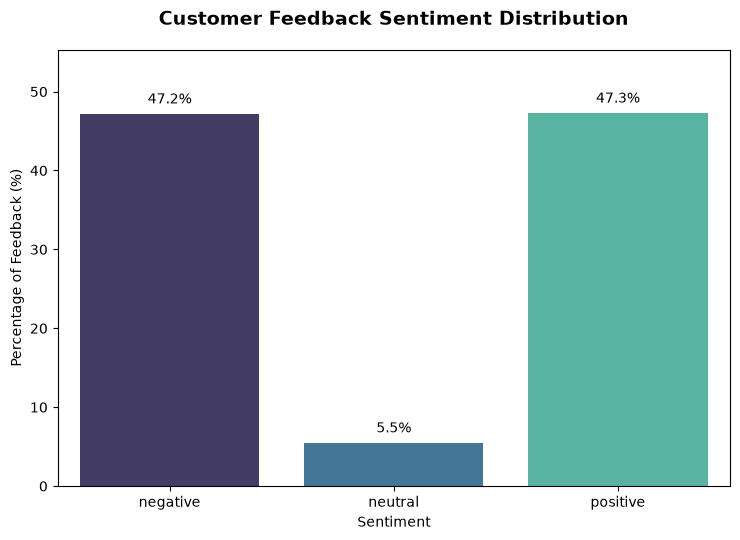

In [11]:
# Plot sentiment distribution with improved spacing

plt.figure(figsize=(7.5, 5.5))

sentiment_order = [
    "negative",
    "neutral",
    "positive"
]

gradient_palette = sns.color_palette(
    "mako",
    n_colors=3
)

ax = sns.barplot(
    data=sentiment_summary,
    x="sentiment",
    y="percentage",
    order=sentiment_order,
    palette=gradient_palette
)

plt.title(
    "Customer Feedback Sentiment Distribution",
    fontsize=14,
    fontweight="bold",
    pad=18
)

plt.xlabel("Sentiment")
plt.ylabel("Percentage of Feedback (%)")

# Create extra space above the bars
ax.set_ylim(
    0,
    sentiment_summary["percentage"].max() + 8
)

# Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=5,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [12]:
positive_feedback = feedback_clean.loc[
    feedback_clean["sentiment"] == "positive",
    "feedback"
]

negative_feedback = feedback_clean.loc[
    feedback_clean["sentiment"] == "negative",
    "feedback"
]

print("Positive feedback:", len(positive_feedback))
print("Negative feedback:", len(negative_feedback))

Positive feedback: 456
Negative feedback: 455


In [13]:
def get_top_terms(texts, top_n=20):

    vectorizer = CountVectorizer(
        stop_words="english",
        lowercase=True,
        ngram_range=(1, 2),
        min_df=3
    )

    term_matrix = vectorizer.fit_transform(texts)

    term_counts = np.asarray(
        term_matrix.sum(axis=0)
    ).ravel()

    terms = vectorizer.get_feature_names_out()

    results = pd.DataFrame({
        "term": terms,
        "count": term_counts
    })

    return (
        results
        .sort_values("count", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

In [14]:
top_positive_terms = get_top_terms(
    positive_feedback
)

top_negative_terms = get_top_terms(
    negative_feedback
)

print("Top positive terms:")
display(top_positive_terms)

print("\nTop negative terms:")
display(top_negative_terms)

Top positive terms:


,term,count
0,experience,257
1,customer,116
2,delivery,115
3,checkout,108
4,support,106
5,app,96
6,process,93
7,delivery experience,87
8,fine,86
9,better,83



Top negative terms:


,term,count
0,experience,261
1,slightly,136
2,delivery,119
3,customer,111
4,support,105
5,app,104
6,checkout,103
7,payment,92
8,delivery experience,89
9,billing,83


In [15]:
# Define business themes using exact words and phrases

theme_keywords = {
    "Delivery": [
        "delivery",
        "delayed"
    ],
    "Customer Support": [
        "customer support",
        "customer care",
        "support"
    ],
    "App": [
        "app"
    ],
    "Checkout / Ordering": [
        "checkout",
        "ordering",
        "buying process",
        "ordering process"
    ],
    "Billing / Payment": [
        "billing",
        "payment",
        "bill",
        "billed"
    ]
}


theme_results = []

for theme, keywords in theme_keywords.items():

    # Match complete words/phrases instead of substrings
    pattern = (
        r"\b(?:"
        + "|".join(re.escape(keyword) for keyword in keywords)
        + r")\b"
    )

    theme_feedback = feedback_clean[
        feedback_clean["feedback"]
        .str.lower()
        .str.contains(pattern, regex=True)
    ]

    positive_count = (
        theme_feedback["sentiment"] == "positive"
    ).sum()

    neutral_count = (
        theme_feedback["sentiment"] == "neutral"
    ).sum()

    negative_count = (
        theme_feedback["sentiment"] == "negative"
    ).sum()

    theme_results.append({
        "Theme": theme,
        "Total_Mentions": len(theme_feedback),
        "Positive": positive_count,
        "Neutral": neutral_count,
        "Negative": negative_count
    })


theme_summary = pd.DataFrame(theme_results)

theme_summary["Positive_Rate"] = (
    theme_summary["Positive"]
    / theme_summary["Total_Mentions"]
    * 100
)

theme_summary["Neutral_Rate"] = (
    theme_summary["Neutral"]
    / theme_summary["Total_Mentions"]
    * 100
)

theme_summary["Negative_Rate"] = (
    theme_summary["Negative"]
    / theme_summary["Total_Mentions"]
    * 100
)

display(theme_summary.round(2))

,Theme,Total_Mentions,Positive,Neutral,Negative,Positive_Rate,Neutral_Rate,Negative_Rate
0,Delivery,288,139,12,137,48.26,4.17,47.57
1,Customer Support,323,161,12,150,49.85,3.72,46.44
2,App,200,90,14,96,45.00,7.00,48.00
3,Checkout / Ordering,377,176,15,186,46.68,3.98,49.34
4,Billing / Payment,256,96,28,132,37.50,10.94,51.56


In [16]:
theme_summary["Neutral_Rate"] = (
    theme_summary["Neutral"]
    / theme_summary["Total_Mentions"]
    * 100
)

theme_plot = theme_summary[
    [
        "Theme",
        "Positive_Rate",
        "Neutral_Rate",
        "Negative_Rate"
    ]
].copy()

theme_plot = theme_plot.set_index("Theme")

display(theme_plot.round(2))

,Positive_Rate,Neutral_Rate,Negative_Rate
Theme,,,
Delivery,48.26,4.17,47.57
Customer Support,49.85,3.72,46.44
App,45.00,7.00,48.00
Checkout / Ordering,46.68,3.98,49.34
Billing / Payment,37.50,10.94,51.56


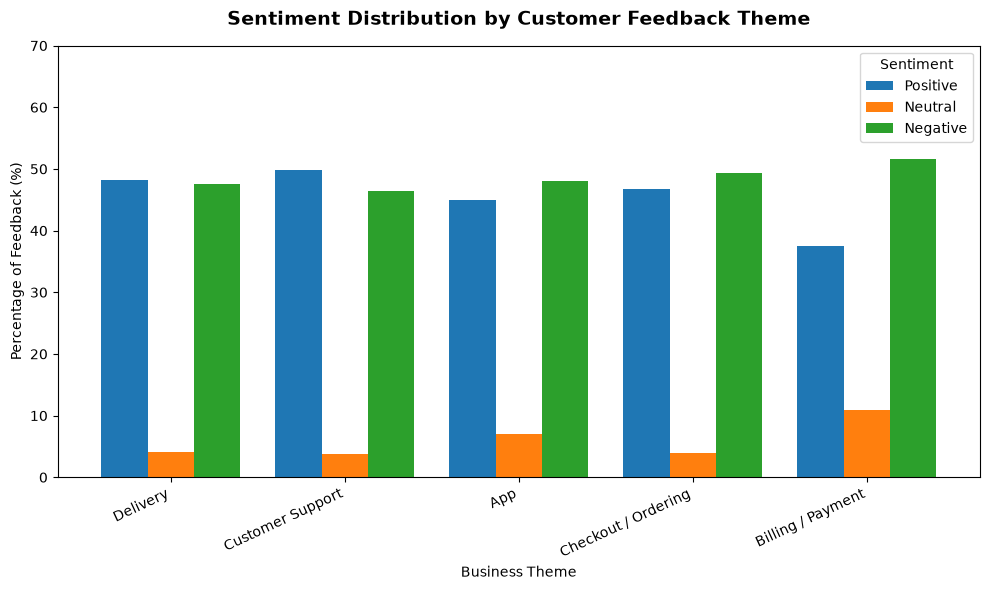

In [17]:
ax = theme_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

plt.title(
    "Sentiment Distribution by Customer Feedback Theme",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Business Theme")
plt.ylabel("Percentage of Feedback (%)")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.legend(
    ["Positive", "Neutral", "Negative"],
    title="Sentiment"
)

plt.ylim(0, 70)

plt.tight_layout()
plt.show()

In [18]:
problem_themes = {
    "App": [
        "app"
    ],
    "Billing / Payment": [
        "billing",
        "payment",
        "bill"
    ],
    "Checkout / Ordering": [
        "checkout",
        "ordering",
        "buying process",
        "ordering process"
    ]
}

for theme, keywords in problem_themes.items():

    pattern = "|".join(keywords)

    negative_examples = feedback_clean[
        (
            feedback_clean["feedback"]
            .str.lower()
            .str.contains(pattern, regex=True)
        )
        &
        (
            feedback_clean["sentiment"] == "negative"
        )
    ]

    print(f"\n{theme} - Negative feedback examples:")

    display(
        negative_examples[
            ["feedback", "sentiment_confidence"]
        ]
        .head(10)
    )


App - Negative feedback examples:


,feedback,sentiment_confidence
0,"customer support was slightly disappointing, b...",0.8986
5,", using the app was inconsistent, but billing ...",0.5910
18,the checkout process seemed better than expect...,0.7336
24,i found the buying process to be slightly disa...,0.9212
26,", the checkout process seemed slightly disappo...",0.7899
28,", the delivery experience turned out to be slo...",0.8841
30,", the experience was decent, but coupon applic...",0.7950
32,", the ordering experience felt slightly disapp...",0.9085
39,", using the app was average, but coupon applic...",0.9068
40,"From my experience, customer support was incon...",0.8737



Billing / Payment - Negative feedback examples:


,feedback,sentiment_confidence
0,"customer support was slightly disappointing, b...",0.8986
5,", using the app was inconsistent, but billing ...",0.5910
6,"the ordering experience felt a bit confusing, ...",0.6080
12,", customer support was frustrating, but paymen...",0.9033
14,", billing and payment were not very impressive",0.8702
23,", the checkout process seemed worse than expec...",0.9072
27,", the ordering experience felt worse than expe...",0.9211
44,"billing and payment were a bit confusing, but ...",0.8630
45,", billing and payment were slightly disappoint...",0.8523
49,", billing and payment were not very impressive...",0.8457



Checkout / Ordering - Negative feedback examples:


,feedback,sentiment_confidence
6,"the ordering experience felt a bit confusing, ...",0.6080
18,the checkout process seemed better than expect...,0.7336
19,", i found the buying process to be inconsistent",0.7726
23,", the checkout process seemed worse than expec...",0.9072
24,i found the buying process to be slightly disa...,0.9212
26,", the checkout process seemed slightly disappo...",0.7899
27,", the ordering experience felt worse than expe...",0.9211
32,", the ordering experience felt slightly disapp...",0.9085
36,"i found the buying process to be frustrating, ...",0.8074
40,"From my experience, customer support was incon...",0.8737


In [19]:
for theme, keywords in problem_themes.items():

    pattern = "|".join(keywords)

    negative_examples = feedback_clean[
        (
            feedback_clean["feedback"]
            .str.lower()
            .str.contains(pattern, regex=True)
        )
        &
        (
            feedback_clean["sentiment"] == "negative"
        )
    ]

    print(f"\n{theme} - Negative feedback examples:")

    with pd.option_context(
        "display.max_colwidth",
        None
    ):
        display(
            negative_examples[
                ["feedback", "sentiment_confidence"]
            ]
            .head(10)
        )


App - Negative feedback examples:


,feedback,sentiment_confidence
0,"customer support was slightly disappointing, but billing had a small discrepancy",0.8986
5,", using the app was inconsistent, but billing had a small discrepancy",0.5910
18,"the checkout process seemed better than expected, but coupon application did not work properly",0.7336
24,"i found the buying process to be slightly disappointing, and the app lagged during checkout which could be improved",0.9212
26,", the checkout process seemed slightly disappointing, though support eventually resolved the issue which could be improved",0.7899
28,", the delivery experience turned out to be slow at times, but coupon application did not work properly but manageable",0.8841
30,", the experience was decent, but coupon application did not work properly and needs some improvement",0.7950
32,", the ordering experience felt slightly disappointing, but communication from support could be better",0.9085
39,", using the app was average, but coupon application did not work properly which could be improved",0.9068
40,"From my experience, customer support was inconsistent, and the app froze briefly during checkout",0.8737



Billing / Payment - Negative feedback examples:


,feedback,sentiment_confidence
0,"customer support was slightly disappointing, but billing had a small discrepancy",0.8986
5,", using the app was inconsistent, but billing had a small discrepancy",0.5910
6,"the ordering experience felt a bit confusing, but payment failed once before succeeding but manageable",0.6080
12,", customer support was frustrating, but payment failed once before succeeding",0.9033
14,", billing and payment were not very impressive",0.8702
23,", the checkout process seemed worse than expected, billing had a small discrepancy",0.9072
27,", the ordering experience felt worse than expected, and the final billed amount differed slightly which could be improved",0.9211
44,"billing and payment were a bit confusing, but coupon application did not work properly",0.8630
45,", billing and payment were slightly disappointing, but billing had a small discrepancy",0.8523
49,", billing and payment were not very impressive, but communication from support could be better and needs some improvement",0.8457



Checkout / Ordering - Negative feedback examples:


,feedback,sentiment_confidence
6,"the ordering experience felt a bit confusing, but payment failed once before succeeding but manageable",0.6080
18,"the checkout process seemed better than expected, but coupon application did not work properly",0.7336
19,", i found the buying process to be inconsistent",0.7726
23,", the checkout process seemed worse than expected, billing had a small discrepancy",0.9072
24,"i found the buying process to be slightly disappointing, and the app lagged during checkout which could be improved",0.9212
26,", the checkout process seemed slightly disappointing, though support eventually resolved the issue which could be improved",0.7899
27,", the ordering experience felt worse than expected, and the final billed amount differed slightly which could be improved",0.9211
32,", the ordering experience felt slightly disappointing, but communication from support could be better",0.9085
36,"i found the buying process to be frustrating, though support eventually resolved the issue but not a major concern",0.8074
40,"From my experience, customer support was inconsistent, and the app froze briefly during checkout",0.8737


In [20]:
theme_keywords = {
    "Delivery": [
        "delivery",
        "delayed"
    ],
    "Customer Support": [
        "customer support",
        "customer care",
        "support"
    ],
    "App": [
        "app"
    ],
    "Checkout / Ordering": [
        "checkout",
        "ordering",
        "buying process",
        "ordering process"
    ],
    "Billing / Payment": [
        "billing",
        "payment",
        "bill",
        "billed"
    ],
    "Coupon / Promotion": [
        "coupon",
        "promotion",
        "promo",
        "discount"
    ]
}


theme_results = []

for theme, keywords in theme_keywords.items():

    pattern = (
        r"\b(?:"
        + "|".join(
            re.escape(keyword)
            for keyword in keywords
        )
        + r")\b"
    )

    theme_feedback = feedback_clean[
        feedback_clean["feedback"]
        .str.lower()
        .str.contains(
            pattern,
            regex=True
        )
    ]

    positive_count = (
        theme_feedback["sentiment"] == "positive"
    ).sum()

    neutral_count = (
        theme_feedback["sentiment"] == "neutral"
    ).sum()

    negative_count = (
        theme_feedback["sentiment"] == "negative"
    ).sum()

    theme_results.append({
        "Theme": theme,
        "Total_Mentions": len(theme_feedback),
        "Positive": positive_count,
        "Neutral": neutral_count,
        "Negative": negative_count
    })


theme_summary = pd.DataFrame(
    theme_results
)

theme_summary["Positive_Rate"] = (
    theme_summary["Positive"]
    / theme_summary["Total_Mentions"]
    * 100
)

theme_summary["Neutral_Rate"] = (
    theme_summary["Neutral"]
    / theme_summary["Total_Mentions"]
    * 100
)

theme_summary["Negative_Rate"] = (
    theme_summary["Negative"]
    / theme_summary["Total_Mentions"]
    * 100
)

display(
    theme_summary.round(2)
)

,Theme,Total_Mentions,Positive,Neutral,Negative,Positive_Rate,Neutral_Rate,Negative_Rate
0,Delivery,288,139,12,137,48.26,4.17,47.57
1,Customer Support,323,161,12,150,49.85,3.72,46.44
2,App,200,90,14,96,45.00,7.00,48.00
3,Checkout / Ordering,377,176,15,186,46.68,3.98,49.34
4,Billing / Payment,256,96,28,132,37.50,10.94,51.56
5,Coupon / Promotion,70,6,7,57,8.57,10.00,81.43


In [21]:
coupon_pattern = (
    r"\b(?:coupon|promotion|promo|discount)\b"
)

coupon_negative_feedback = feedback_clean[
    (
        feedback_clean["feedback"]
        .str.lower()
        .str.contains(
            coupon_pattern,
            regex=True
        )
    )
    &
    (
        feedback_clean["sentiment"] == "negative"
    )
]

print(
    "Negative Coupon / Promotion feedback:",
    len(coupon_negative_feedback)
)

with pd.option_context(
    "display.max_colwidth",
    None
):
    display(
        coupon_negative_feedback[
            ["feedback", "sentiment_confidence"]
        ]
        .head(15)
    )

Negative Coupon / Promotion feedback: 57


,feedback,sentiment_confidence
18,"the checkout process seemed better than expected, but coupon application did not work properly",0.7336
28,", the delivery experience turned out to be slow at times, but coupon application did not work properly but manageable",0.8841
30,", the experience was decent, but coupon application did not work properly and needs some improvement",0.7950
39,", using the app was average, but coupon application did not work properly which could be improved",0.9068
44,"billing and payment were a bit confusing, but coupon application did not work properly",0.8630
78,"my interaction with customer care was not very impressive, but coupon application did not work properly but not a major concern",0.9024
87,"customer support was a bit confusing, but coupon application did not work properly which slightly affected my experience",0.9047
92,", the checkout process seemed mostly fine, but coupon application did not work properly",0.6921
118,"customer support was worse than expected, but coupon application did not work properly which slightly affected my experience",0.9421
124,"billing and payment were worse than expected, but coupon application did not work properly",0.9380


In [22]:
coupon_issue_phrase = (
    "coupon application did not work properly"
)

coupon_issue_count = (
    feedback_clean["feedback"]
    .str.lower()
    .str.contains(
        coupon_issue_phrase,
        regex=False
    )
    .sum()
)

coupon_issue_negative_count = (
    feedback_clean[
        feedback_clean["sentiment"] == "negative"
    ]["feedback"]
    .str.lower()
    .str.contains(
        coupon_issue_phrase,
        regex=False
    )
    .sum()
)

print(
    "Total mentions of coupon application issue:",
    coupon_issue_count
)

print(
    "Negative feedback containing this issue:",
    coupon_issue_negative_count
)

Total mentions of coupon application issue: 70
Negative feedback containing this issue: 57


In [23]:
custom_stop_words = set(ENGLISH_STOP_WORDS) - {
    "not",
    "no",
    "nor",
    "never"
}


def get_negative_theme_phrases(
    theme,
    keywords,
    top_n=10
):

    pattern = (
        r"\b(?:"
        + "|".join(
            re.escape(keyword)
            for keyword in keywords
        )
        + r")\b"
    )

    theme_negative = feedback_clean[
        (
            feedback_clean["feedback"]
            .str.lower()
            .str.contains(
                pattern,
                regex=True
            )
        )
        &
        (
            feedback_clean["sentiment"]
            == "negative"
        )
    ]

    vectorizer = CountVectorizer(
        stop_words=list(custom_stop_words),
        lowercase=True,
        ngram_range=(2, 4),
        min_df=3
    )

    term_matrix = vectorizer.fit_transform(
        theme_negative["feedback"]
    )

    term_counts = np.asarray(
        term_matrix.sum(axis=0)
    ).ravel()

    terms = vectorizer.get_feature_names_out()

    phrase_summary = pd.DataFrame({
        "Phrase": terms,
        "Count": term_counts
    })

    return (
        phrase_summary
        .sort_values(
            "Count",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


for theme, keywords in theme_keywords.items():

    print(f"\n{theme} - Common negative phrases:")

    display(
        get_negative_theme_phrases(
            theme,
            keywords
        )
    )


Delivery - Common negative phrases:


,Phrase,Count
0,delivery experience,89
1,experience turned,47
2,delivery experience turned,47
3,browsing delivery,42
4,browsing delivery experience,42
5,delivery delayed couple days,30
6,pickup delayed,30
7,return pickup,30
8,return pickup delayed,30
9,delivery delayed,30



Customer Support - Common negative phrases:


,Phrase,Count
0,customer care,61
1,customer support,50
2,interaction customer,43
3,interaction customer care,43
4,communication support better,28
5,support better,28
6,communication support,28
7,support eventually resolved issue,27
8,resolved issue,27
9,support eventually,27



App - Common negative phrases:


...

,Phrase,Count
0,experience felt,59
1,ordering experience felt,59
2,ordering experience,59
3,checkout process,42
4,buying process,37
5,app froze briefly checkout,31
6,froze briefly,31
7,froze briefly checkout,31
8,briefly checkout,31
9,slightly disappointing,31



Billing / Payment - Common negative phrases:


,Phrase,Count
0,billing payment,55
1,payment failed succeeding,37
2,payment failed,37
3,failed succeeding,37
4,billing small,28
5,small discrepancy,28
6,billing small discrepancy,28
7,final billed differed,23
8,final billed differed slightly,23
9,differed slightly,23



Coupon / Promotion - Common negative phrases:


,Phrase,Count
0,application did,57
1,application did not,57
2,did not,57
3,application did not work,57
4,coupon application did,57
5,coupon application,57
6,did not work properly,57
7,did not work,57
8,coupon application did not,57
9,not work,57


In [24]:
def get_positive_theme_phrases(
    theme,
    keywords,
    top_n=10
):

    pattern = (
        r"\b(?:"
        + "|".join(
            re.escape(keyword)
            for keyword in keywords
        )
        + r")\b"
    )

    theme_positive = feedback_clean[
        (
            feedback_clean["feedback"]
            .str.lower()
            .str.contains(
                pattern,
                regex=True
            )
        )
        &
        (
            feedback_clean["sentiment"]
            == "positive"
        )
    ]

    vectorizer = CountVectorizer(
        stop_words=list(custom_stop_words),
        lowercase=True,
        ngram_range=(2, 4),
        min_df=3
    )

    term_matrix = vectorizer.fit_transform(
        theme_positive["feedback"]
    )

    term_counts = np.asarray(
        term_matrix.sum(axis=0)
    ).ravel()

    terms = vectorizer.get_feature_names_out()

    phrase_summary = pd.DataFrame({
        "Phrase": terms,
        "Count": term_counts
    })

    return (
        phrase_summary
        .sort_values(
            "Count",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


for theme, keywords in theme_keywords.items():

    print(f"\n{theme} - Common positive phrases:")

    display(
        get_positive_theme_phrases(
            theme,
            keywords
        )
    )


Delivery - Common positive phrases:


,Phrase,Count
0,delivery experience,87
1,browsing delivery,45
2,browsing delivery experience,45
3,delivery experience turned,42
4,experience turned,42
5,return pickup delayed,33
6,return pickup,33
7,pickup delayed,33
8,delivery delayed,25
9,couple days,25



Customer Support - Common positive phrases:


,Phrase,Count
0,customer care,71
1,customer support,45
2,interaction customer,42
3,interaction customer care,42
4,support better,39
5,support eventually resolved,32
6,support eventually,32
7,support eventually resolved issue,32
8,eventually resolved issue,32
9,eventually resolved,32



App - Common positive phrases:


...

,Phrase,Count
0,buying process,46
1,checkout process,44
2,ordering experience felt,38
3,experience felt,38
4,ordering experience,38
5,lagged checkout,34
6,app lagged checkout,34
7,app lagged,34
8,froze briefly,29
9,froze briefly checkout,29



Billing / Payment - Common positive phrases:


,Phrase,Count
0,billing payment,32
1,billing small discrepancy,31
2,billing small,31
3,small discrepancy,31
4,billed differed,27
5,billed differed slightly,27
6,final billed differed,27
7,final billed,27
8,differed slightly,27
9,final billed differed slightly,27



Coupon / Promotion - Common positive phrases:


,Phrase,Count
0,application did,6
1,application did not,6
2,application did not work,6
3,coupon application,6
4,coupon application did,6
5,coupon application did not,6
6,did not,6
7,did not work properly,6
8,did not work,6
9,not work,6


In [25]:
clause_records = []

for feedback_id, feedback in feedback_clean["feedback"].items():

    clauses = re.split(
        r"\b(?:but|however|although|though|yet)\b|[,;]",
        feedback,
        flags=re.IGNORECASE
    )

    for clause in clauses:

        clause = clause.strip()

        if len(clause.split()) >= 3:

            clause_records.append({
                "feedback_id": feedback_id,
                "clause": clause
            })


clauses_df = pd.DataFrame(
    clause_records
)

print(
    "Original feedback comments:",
    len(feedback_clean)
)

print(
    "Extracted clauses:",
    len(clauses_df)
)

display(
    clauses_df.head(15)
)

Original feedback comments: 964
Extracted clauses: 2160


,feedback_id,clause
0,0,customer support was slightly disappointing
1,0,billing had a small discrepancy
2,1,the experience was decent
3,1,and the final billed amount differed slightly ...
4,2,Superr 10 out of 10
5,3,wow nice option
6,4,i found the buying process to be quite good
7,4,the return pickup was delayed which slightly a...
8,5,using the app was inconsistent
9,5,billing had a small discrepancy


In [26]:
all_clauses = clauses_df["clause"].tolist()

clause_sentiment_results = sentiment_pipeline(
    all_clauses,
    batch_size=32,
    truncation=True
)

clauses_df["sentiment"] = [
    result["label"].lower()
    for result in clause_sentiment_results
]

clauses_df["sentiment_confidence"] = [
    round(result["score"], 4)
    for result in clause_sentiment_results
]


print(
    clauses_df["sentiment"]
    .value_counts()
)

display(
    clauses_df.head(20)
)

sentiment
negative    924
neutral     639
positive    597
Name: count, dtype: int64


,feedback_id,clause,sentiment,sentiment_confidence
0,0,customer support was slightly disappointing,negative,0.9093
1,0,billing had a small discrepancy,neutral,0.8311
2,1,the experience was decent,positive,0.9294
3,1,and the final billed amount differed slightly ...,neutral,0.5950
4,2,Superr 10 out of 10,positive,0.7102
5,3,wow nice option,positive,0.9327
6,4,i found the buying process to be quite good,positive,0.9384
7,4,the return pickup was delayed which slightly a...,negative,0.8206
8,5,using the app was inconsistent,negative,0.7601
9,5,billing had a small discrepancy,neutral,0.8311


In [27]:
clause_theme_results = []

for theme, keywords in theme_keywords.items():

    pattern = (
        r"\b(?:"
        + "|".join(
            re.escape(keyword)
            for keyword in keywords
        )
        + r")\b"
    )

    theme_clauses = clauses_df[
        clauses_df["clause"]
        .str.lower()
        .str.contains(
            pattern,
            regex=True
        )
    ]

    positive_count = (
        theme_clauses["sentiment"] == "positive"
    ).sum()

    neutral_count = (
        theme_clauses["sentiment"] == "neutral"
    ).sum()

    negative_count = (
        theme_clauses["sentiment"] == "negative"
    ).sum()

    clause_theme_results.append({
        "Theme": theme,
        "Total_Clauses": len(theme_clauses),
        "Positive": positive_count,
        "Neutral": neutral_count,
        "Negative": negative_count
    })


clause_theme_summary = pd.DataFrame(
    clause_theme_results
)

clause_theme_summary["Positive_Rate"] = (
    clause_theme_summary["Positive"]
    / clause_theme_summary["Total_Clauses"]
    * 100
)

clause_theme_summary["Neutral_Rate"] = (
    clause_theme_summary["Neutral"]
    / clause_theme_summary["Total_Clauses"]
    * 100
)

clause_theme_summary["Negative_Rate"] = (
    clause_theme_summary["Negative"]
    / clause_theme_summary["Total_Clauses"]
    * 100
)

display(
    clause_theme_summary.round(2)
)

,Theme,Total_Clauses,Positive,Neutral,Negative,Positive_Rate,Neutral_Rate,Negative_Rate
0,Delivery,309,45,93,171,14.56,30.10,55.34
1,Customer Support,355,104,152,99,29.30,42.82,27.89
2,App,214,44,4,166,20.56,1.87,77.57
3,Checkout / Ordering,411,148,1,262,36.01,0.24,63.75
4,Billing / Payment,276,43,152,81,15.58,55.07,29.35
5,Coupon / Promotion,70,0,0,70,0.00,0.00,100.00


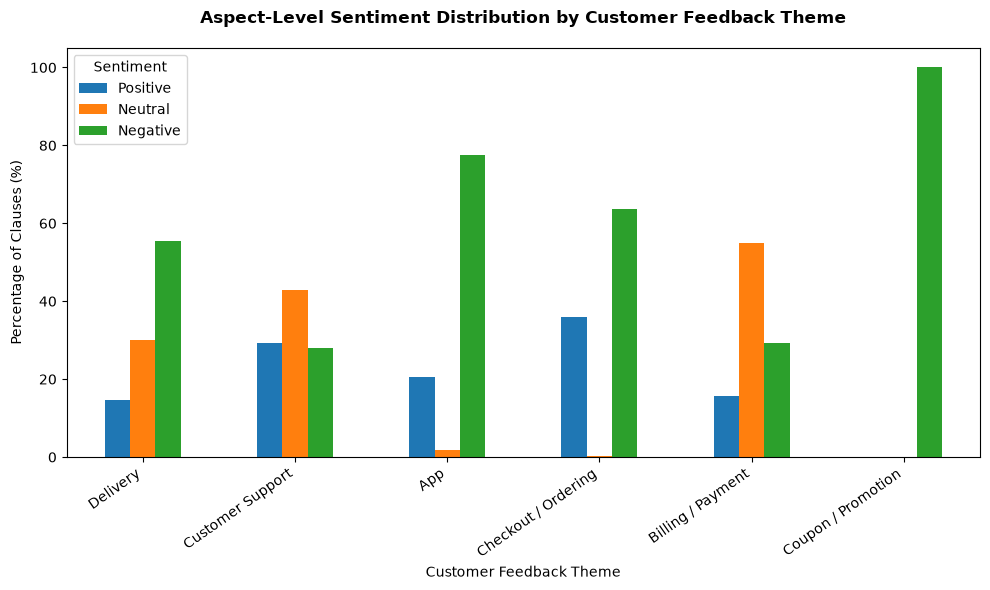

In [28]:
theme_plot = (
    clause_theme_summary[
        [
            "Theme",
            "Positive_Rate",
            "Neutral_Rate",
            "Negative_Rate"
        ]
    ]
    .set_index("Theme")
)

ax = theme_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Aspect-Level Sentiment Distribution by Customer Feedback Theme",
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Customer Feedback Theme"
)

ax.set_ylabel(
    "Percentage of Clauses (%)"
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)

ax.legend(
    [
        "Positive",
        "Neutral",
        "Negative"
    ],
    title="Sentiment"
)

plt.tight_layout()
plt.show()

In [33]:
def get_clause_theme_phrases(
    theme,
    keywords,
    sentiment_label="negative",
    top_n=10
):

    pattern = (
        r"\b(?:"
        + "|".join(
            re.escape(keyword)
            for keyword in keywords
        )
        + r")\b"
    )

    selected_clauses = clauses_df[
        (
            clauses_df["clause"]
            .str.lower()
            .str.contains(
                pattern,
                regex=True
            )
        )
        &
        (
            clauses_df["sentiment"]
            == sentiment_label
        )
    ]

    # If there are no matching clauses, return an empty table
    if selected_clauses.empty:
        return pd.DataFrame(
            columns=[
                "Phrase",
                "Count"
            ]
        )

    vectorizer = CountVectorizer(
        stop_words=list(custom_stop_words),
        lowercase=True,
        ngram_range=(2, 4),
        min_df=3
    )

    try:

        term_matrix = vectorizer.fit_transform(
            selected_clauses["clause"]
        )

    except ValueError:

        return pd.DataFrame(
            columns=[
                "Phrase",
                "Count"
            ]
        )

    term_counts = np.asarray(
        term_matrix.sum(axis=0)
    ).ravel()

    terms = vectorizer.get_feature_names_out()

    phrase_summary = pd.DataFrame({
        "Phrase": terms,
        "Count": term_counts
    })

    return (
        phrase_summary
        .sort_values(
            "Count",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )

In [35]:
for theme, keywords in theme_keywords.items():

    print(
        f"\n{theme} - Clause-Level Positive Phrases:"
    )

    display(
        get_clause_theme_phrases(
            theme,
            keywords,
            sentiment_label="positive"
        )
    )


Delivery - Clause-Level Positive Phrases:


,Phrase,Count
0,delivery experience,43
1,delivery experience turned,43
2,experience turned,43
3,delivery experience turned smooth,10
4,turned smooth,10
5,experience turned smooth,10
6,delivery experience turned decent,9
7,turned decent,9
8,experience turned decent,9
9,delivery experience turned satisfactory,6



Customer Support - Clause-Level Positive Phrases:


,Phrase,Count
0,customer support,53
1,customer care,49
2,interaction customer,49
3,interaction customer care,49
4,better expected,17
5,quite good,16
6,fairly efficient,12
7,support better,12
8,customer support better expected,11
9,support better expected,11



App - Clause-Level Positive Phrases:


...

,Phrase,Count
0,checkout process,55
1,buying process,50
2,ordering experience felt,41
3,experience felt,41
4,ordering experience,41
5,better expected,18
6,quite good,18
7,process satisfactory,16
8,process better expected,15
9,process better,15



Billing / Payment - Clause-Level Positive Phrases:


,Phrase,Count
0,billing payment,42
1,payment satisfactory,10
2,billing payment satisfactory,10
3,billing payment fine,9
4,payment fine,9
5,quite good,6
6,payment quite good,6
7,billing payment quite,6
8,billing payment pleasant,6
9,payment pleasant,6



Coupon / Promotion - Clause-Level Positive Phrases:


,Phrase,Count


In [36]:
business_insights = clause_theme_summary[
    [
        "Theme",
        "Total_Clauses",
        "Positive_Rate",
        "Neutral_Rate",
        "Negative_Rate"
    ]
].copy()


main_findings = {
    "Delivery": (
        "Delivery delays and delayed return pickups were recurring issues."
    ),

    "Customer Support": (
        "Feedback was relatively balanced, although slow or unclear "
        "support interactions appeared in negative comments."
    ),

    "App": (
        "App lagging and freezing during checkout were the main "
        "recurring problems."
    ),

    "Checkout / Ordering": (
        "Checkout friction was frequently associated with app lagging "
        "or freezing and disappointing ordering experiences."
    ),

    "Billing / Payment": (
        "Payment failures, billing discrepancies and inconsistent "
        "payment experiences appeared repeatedly."
    ),

    "Coupon / Promotion": (
        "Coupon application failures were consistently identified "
        "in the feedback."
    )
}


business_actions = {
    "Delivery": (
        "Improve delivery reliability and the return pickup process."
    ),

    "Customer Support": (
        "Improve response speed and communication clarity while "
        "maintaining successful issue resolution."
    ),

    "App": (
        "Prioritise app stability and performance, especially "
        "during checkout."
    ),

    "Checkout / Ordering": (
        "Reduce checkout friction and investigate technical issues "
        "affecting the ordering process."
    ),

    "Billing / Payment": (
        "Improve payment reliability and verify billing accuracy."
    ),

    "Coupon / Promotion": (
        "Investigate coupon redemption logic and test the promotion "
        "application process."
    )
}


business_insights["Main_Finding"] = (
    business_insights["Theme"]
    .map(main_findings)
)

business_insights["Recommended_Action"] = (
    business_insights["Theme"]
    .map(business_actions)
)


business_insights = (
    business_insights
    .sort_values(
        "Negative_Rate",
        ascending=False
    )
    .reset_index(drop=True)
)


display(
    business_insights.round(2)
)

,Theme,Total_Clauses,Positive_Rate,Neutral_Rate,Negative_Rate,Main_Finding,Recommended_Action
0,Coupon / Promotion,70,0.00,0.00,100.00,Coupon application failures were consistently ...,Investigate coupon redemption logic and test t...
1,App,214,20.56,1.87,77.57,App lagging and freezing during checkout were ...,"Prioritise app stability and performance, espe..."
2,Checkout / Ordering,411,36.01,0.24,63.75,Checkout friction was frequently associated wi...,Reduce checkout friction and investigate techn...
3,Delivery,309,14.56,30.10,55.34,Delivery delays and delayed return pickups wer...,Improve delivery reliability and the return pi...
4,Billing / Payment,276,15.58,55.07,29.35,"Payment failures, billing discrepancies and in...",Improve payment reliability and verify billing...
5,Customer Support,355,29.30,42.82,27.89,"Feedback was relatively balanced, although slo...",Improve response speed and communication clari...


In [37]:
confidence_summary = (
    clauses_df
    .groupby("sentiment")["sentiment_confidence"]
    .agg(
        Count="count",
        Mean_Confidence="mean",
        Median_Confidence="median",
        Min_Confidence="min",
        Max_Confidence="max"
    )
    .round(4)
)

display(confidence_summary)


low_confidence_60 = (
    clauses_df["sentiment_confidence"] < 0.60
).sum()

low_confidence_70 = (
    clauses_df["sentiment_confidence"] < 0.70
).sum()


print(
    "Clauses with confidence below 0.60:",
    low_confidence_60
)

print(
    "Percentage below 0.60:",
    round(
        low_confidence_60 / len(clauses_df) * 100,
        2
    ),
    "%"
)

print()

print(
    "Clauses with confidence below 0.70:",
    low_confidence_70
)

print(
    "Percentage below 0.70:",
    round(
        low_confidence_70 / len(clauses_df) * 100,
        2
    ),
    "%"
)

,Count,Mean_Confidence,Median_Confidence,Min_Confidence,Max_Confidence
sentiment,,,,,
negative,924,0.7939,0.8341,0.4881,0.9391
neutral,639,0.7096,0.6930,0.4832,0.8423
positive,597,0.8627,0.9090,0.5010,0.9811


Clauses with confidence below 0.60: 234
Percentage below 0.60: 10.83 %

Clauses with confidence below 0.70: 569
Percentage below 0.70: 26.34 %


In [38]:
lowest_confidence_clauses = (
    clauses_df[
        [
            "feedback_id",
            "clause",
            "sentiment",
            "sentiment_confidence"
        ]
    ]
    .sort_values(
        "sentiment_confidence",
        ascending=True
    )
    .head(20)
)

with pd.option_context(
    "display.max_colwidth",
    None
):
    display(
        lowest_confidence_clauses
    )

,feedback_id,clause,sentiment,sentiment_confidence
60,33,its like any other what to tell new nothing,neutral,0.4832
1962,876,no complaints really,neutral,0.4839
1813,808,payment failed once before succeeding which could be improved,negative,0.4881
57,31,payment failed once before succeeding which could be improved,negative,0.4881
1032,456,payment failed once before succeeding which could be improved,negative,0.4881
302,139,payment failed once before succeeding which could be improved,negative,0.4881
2059,917,payment failed once before succeeding which could be improved,negative,0.4881
1782,795,payment failed once before succeeding which could be improved,negative,0.4881
218,104,payment failed once before succeeding which could be improved,negative,0.4881
1959,875,Billing and payment were a bit confusing,neutral,0.4911


In [39]:
clause_repetition = (
    clauses_df["clause"]
    .str.lower()
    .str.strip()
    .value_counts()
    .reset_index()
)

clause_repetition.columns = [
    "Clause",
    "Count"
]


unique_clauses = (
    clauses_df["clause"]
    .str.lower()
    .str.strip()
    .nunique()
)

repeated_clause_rows = (
    clauses_df["clause"]
    .str.lower()
    .str.strip()
    .duplicated()
    .sum()
)


print(
    "Total clauses:",
    len(clauses_df)
)

print(
    "Unique clauses:",
    unique_clauses
)

print(
    "Repeated clause rows:",
    repeated_clause_rows
)

print(
    "Percentage of repeated clause rows:",
    round(
        repeated_clause_rows
        / len(clauses_df)
        * 100,
        2
    ),
    "%"
)

print()

print(
    "Most repeated clauses:"
)

display(
    clause_repetition.head(15)
)

Total clauses: 2160
Unique clauses: 267
Repeated clause rows: 1893
Percentage of repeated clause rows: 87.64 %

Most repeated clauses:


,Clause,Count
0,not a major concern,108
1,from browsing to delivery,92
2,from my experience,71
3,everything worked fine,58
4,coupon application did not work properly,55
5,billing had a small discrepancy,50
6,and the app lagged during checkout,45
7,support eventually resolved the issue,44
8,communication from support could be better,43
9,the delivery was delayed by a couple of days,43


In [40]:
unique_clauses_df = clauses_df.copy()

unique_clauses_df["normalized_clause"] = (
    unique_clauses_df["clause"]
    .str.lower()
    .str.strip()
)

unique_clauses_df = (
    unique_clauses_df
    .drop_duplicates(
        subset="normalized_clause"
    )
    .reset_index(drop=True)
)


print(
    "Original clauses:",
    len(clauses_df)
)

print(
    "Unique clauses:",
    len(unique_clauses_df)
)


unique_theme_results = []

for theme, keywords in theme_keywords.items():

    pattern = (
        r"\b(?:"
        + "|".join(
            re.escape(keyword)
            for keyword in keywords
        )
        + r")\b"
    )

    theme_clauses = unique_clauses_df[
        unique_clauses_df["clause"]
        .str.lower()
        .str.contains(
            pattern,
            regex=True
        )
    ]

    positive_count = (
        theme_clauses["sentiment"] == "positive"
    ).sum()

    neutral_count = (
        theme_clauses["sentiment"] == "neutral"
    ).sum()

    negative_count = (
        theme_clauses["sentiment"] == "negative"
    ).sum()

    unique_theme_results.append({
        "Theme": theme,
        "Total_Unique_Clauses": len(theme_clauses),
        "Positive": positive_count,
        "Neutral": neutral_count,
        "Negative": negative_count
    })


unique_theme_summary = pd.DataFrame(
    unique_theme_results
)

unique_theme_summary["Positive_Rate"] = (
    unique_theme_summary["Positive"]
    / unique_theme_summary["Total_Unique_Clauses"]
    * 100
)

unique_theme_summary["Neutral_Rate"] = (
    unique_theme_summary["Neutral"]
    / unique_theme_summary["Total_Unique_Clauses"]
    * 100
)

unique_theme_summary["Negative_Rate"] = (
    unique_theme_summary["Negative"]
    / unique_theme_summary["Total_Unique_Clauses"]
    * 100
)


display(
    unique_theme_summary.round(2)
)

Original clauses: 2160
Unique clauses: 267


,Theme,Total_Unique_Clauses,Positive,Neutral,Negative,Positive_Rate,Neutral_Rate,Negative_Rate
0,Delivery,28,10,2,16,35.71,7.14,57.14
1,Customer Support,46,19,8,19,41.30,17.39,41.30
2,App,27,11,1,15,40.74,3.70,55.56
3,Checkout / Ordering,60,27,1,32,45.00,1.67,53.33
4,Billing / Payment,29,9,8,12,31.03,27.59,41.38
5,Coupon / Promotion,4,0,0,4,0.00,0.00,100.00


In [41]:
sentiment_comparison = (
    clause_theme_summary[
        [
            "Theme",
            "Negative_Rate"
        ]
    ]
    .rename(
        columns={
            "Negative_Rate": "Negative_Rate_All_Clauses"
        }
    )
    .merge(
        unique_theme_summary[
            [
                "Theme",
                "Total_Unique_Clauses",
                "Negative_Rate"
            ]
        ].rename(
            columns={
                "Negative_Rate": "Negative_Rate_Unique_Clauses"
            }
        ),
        on="Theme"
    )
)

sentiment_comparison["Difference"] = (
    sentiment_comparison[
        "Negative_Rate_All_Clauses"
    ]
    -
    sentiment_comparison[
        "Negative_Rate_Unique_Clauses"
    ]
)

display(
    sentiment_comparison.round(2)
)

,Theme,Negative_Rate_All_Clauses,Total_Unique_Clauses,Negative_Rate_Unique_Clauses,Difference
0,Delivery,55.34,28,57.14,-1.80
1,Customer Support,27.89,46,41.30,-13.42
2,App,77.57,27,55.56,22.01
3,Checkout / Ordering,63.75,60,53.33,10.41
4,Billing / Payment,29.35,29,41.38,-12.03
5,Coupon / Promotion,100.00,4,100.00,0.00


<b> Methodological Note: Repeated Feedback Patterns</b>

-- The 2,160 extracted clauses contained only 267 unique clauses,<br>
showing that the feedback dataset contains a high level of repeated<br>
or template-based language.

-- To check whether these repetitions were influencing the results,<br>
the theme-level sentiment analysis was repeated using only unique<br>
clauses.

-- Delivery remained almost unchanged, with the negative rate moving<br>
from 55.34% to 57.14%.

-- App and Checkout / Ordering remained mostly negative after removing<br>
duplicates, although their negative rates decreased to 55.56% and<br>
53.33%. This suggests that repeated phrases amplified the original<br>
negative percentages.

-- Customer Support and Billing / Payment became more negative after<br>
deduplication, showing that repeated clauses can influence the results<br>
in either direction.

-- Coupon / Promotion remained 100% negative, but this result was based<br>
on only four unique clauses and should therefore be interpreted with<br>
caution.

-- For this reason, the final business insights focus mainly on patterns<br>
that remained consistent across both the complete and deduplicated<br>
clause analyses rather than relying only on raw phrase frequency.

<b> Final NLP Findings </b>

-- The overall sentiment analysis classified the customer feedback into<br>
positive, neutral and negative categories using a pre-trained<br>
Transformer model.

-- At comment level, the sentiment distribution was almost balanced<br>
between positive and negative feedback, with only a small proportion<br>
classified as neutral.

-- Because many comments contained mixed opinions, the feedback was also<br>
split into smaller clauses and sentiment was classified at clause level.<br>
This provided a more accurate view of sentiment for individual business<br>
themes.

-- Coupon / Promotion showed the strongest negative signal. The main<br>
recurring issue was that coupon application did not work properly.<br>
However, this theme contained only a small number of unique clauses.

-- App feedback was mainly associated with lagging and freezing during<br>
checkout. The theme remained mostly negative even after repeated clauses<br>
were removed.

-- Checkout / Ordering also remained mostly negative after deduplication,<br>
with many issues connected to app performance and checkout friction.

-- Delivery showed a consistent negative pattern in both analyses,<br>
mainly related to delivery delays and delayed return pickups.

-- Billing / Payment included payment failures, billing discrepancies and<br>
differences in the final billed amount. A large proportion of these<br>
clauses were classified as neutral.

-- Customer Support produced more balanced results. Positive feedback<br>
included efficient support and better-than-expected experiences, while<br>
negative feedback included slow responses and unclear communication.

-- The dataset contained a high level of repeated or template-based<br>
language. Therefore, both complete and deduplicated clause analyses were<br>
used when interpreting the final business insights.

-- The main recommended priorities are improving coupon functionality,<br>
app stability, checkout reliability and delivery performance.

In [42]:
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"


feedback_clean["character_count"] = (
    feedback_clean["feedback"]
    .str.len()
)

feedback_clean["word_count"] = (
    feedback_clean["feedback"]
    .str.split()
    .str.len()
)


feedback_clean.to_csv(
    PROCESSED_DATA / "customer_feedback_sentiment.csv",
    index=False
)


clauses_df.to_csv(
    PROCESSED_DATA / "customer_feedback_clauses.csv",
    index=False
)


clause_theme_summary.to_csv(
    PROCESSED_DATA / "feedback_theme_sentiment_summary.csv",
    index=False
)


unique_theme_summary.to_csv(
    PROCESSED_DATA / "feedback_unique_theme_summary.csv",
    index=False
)


business_insights.to_csv(
    PROCESSED_DATA / "feedback_business_insights.csv",
    index=False
)


print("NLP outputs saved successfully.")

NLP outputs saved successfully.


In [43]:
sorted(
    file.name
    for file in PROCESSED_DATA.glob("*.csv")
)

['customer_features.csv',
 'customer_feedback_clauses.csv',
 'customer_feedback_sentiment.csv',
 'customer_segment_summary.csv',
 'customer_segments.csv',
 'feedback_business_insights.csv',
 'feedback_theme_sentiment_summary.csv',
 'feedback_unique_theme_summary.csv',
 'master_dataset.csv']

In [44]:
print(
    "Comment-level sentiment:",
    feedback_clean.shape
)

print(
    "Clause-level sentiment:",
    clauses_df.shape
)

print(
    "Theme summary:",
    clause_theme_summary.shape
)

print(
    "Unique theme summary:",
    unique_theme_summary.shape
)

print(
    "Business insights:",
    business_insights.shape
)

print()

print(
    "Missing sentiment labels:",
    feedback_clean["sentiment"].isna().sum()
)

print(
    "Missing clause sentiment labels:",
    clauses_df["sentiment"].isna().sum()
)

print()

print(
    "Comment sentiment values:",
    sorted(
        feedback_clean["sentiment"].unique()
    )
)

print(
    "Clause sentiment values:",
    sorted(
        clauses_df["sentiment"].unique()
    )
)

Comment-level sentiment: (964, 5)
Clause-level sentiment: (2160, 4)
Theme summary: (6, 8)
Unique theme summary: (6, 8)
Business insights: (6, 7)

Missing sentiment labels: 0
Missing clause sentiment labels: 0

Comment sentiment values: ['negative', 'neutral', 'positive']
Clause sentiment values: ['negative', 'neutral', 'positive']
